## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [2]:
# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
num_workers = 4 if device.type == 'cuda' else 0
print(f"The code will run on {device} with {num_workers} data loader workers.")

The code will run on mps with 0 data loader workers.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y
    

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
# Data: transforms, train/validation split and loaders
CNN_SIZE = 128
RESNET_SIZE = 224
class_names = ['hotdog', 'not hotdog']


def make_transform(size, augment):
    steps = [transforms.Resize((size, size))]
    if augment:
        steps += [transforms.RandomResizedCrop(size, scale=(0.7, 1.0)),
                  transforms.RandomHorizontalFlip(),
                  transforms.ColorJitter(0.2, 0.2, 0.2)]
    return transforms.Compose(steps + [transforms.ToTensor()])


n_train = len(Hotdog_NotHotdog(train=True, transform=None))
perm = torch.randperm(n_train, generator=torch.Generator().manual_seed(0)).tolist()
n_val = int(0.15 * n_train)
val_idx, train_idx = perm[:n_val], perm[n_val:]


def make_loaders(size, augment, batch_size=64):
    train_set = Subset(Hotdog_NotHotdog(train=True, transform=make_transform(size, augment)), train_idx)
    val_set = Subset(Hotdog_NotHotdog(train=True, transform=make_transform(size, False)), val_idx)
    test_set = Hotdog_NotHotdog(train=False, transform=make_transform(size, False))
    return (DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers),
            DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers),
            DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers))


print(f"train: {len(train_idx)}, validation: {len(val_idx)}, "
      f"test: {len(Hotdog_NotHotdog(train=False, transform=None))} images")

train: 1740, validation: 307, test: 1862 images


Let's look at some images from our data 

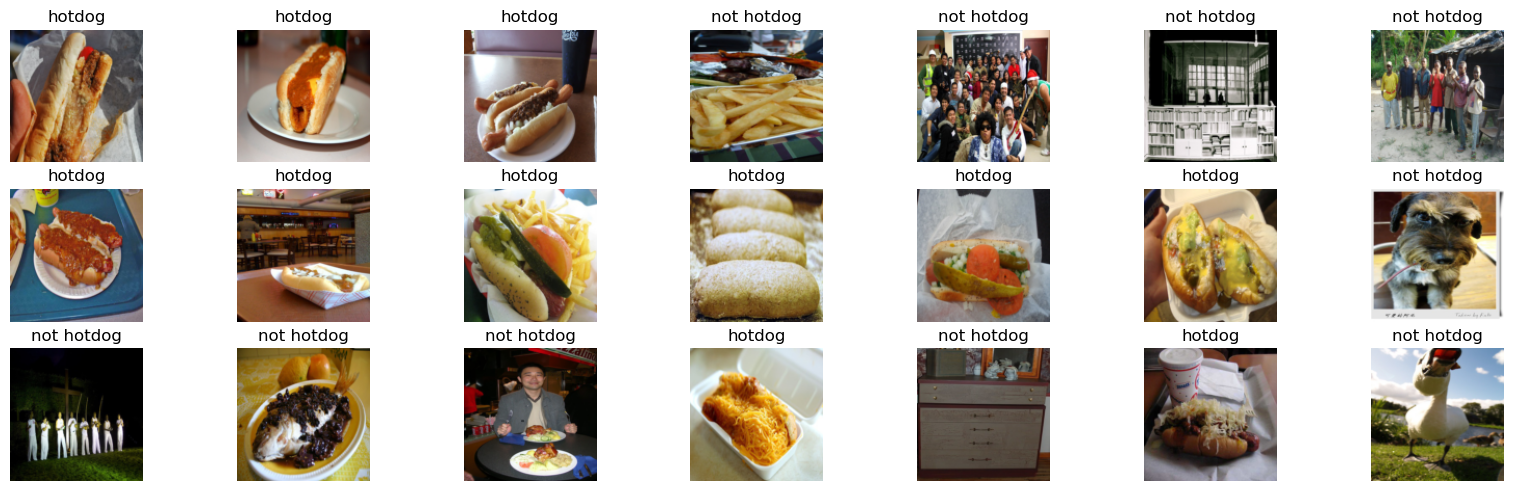

In [5]:
images, labels = next(iter(make_loaders(CNN_SIZE, augment=False)[0]))
plt.figure(figsize=(20, 10))
for i in range(21):
    plt.subplot(5, 7, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.show()

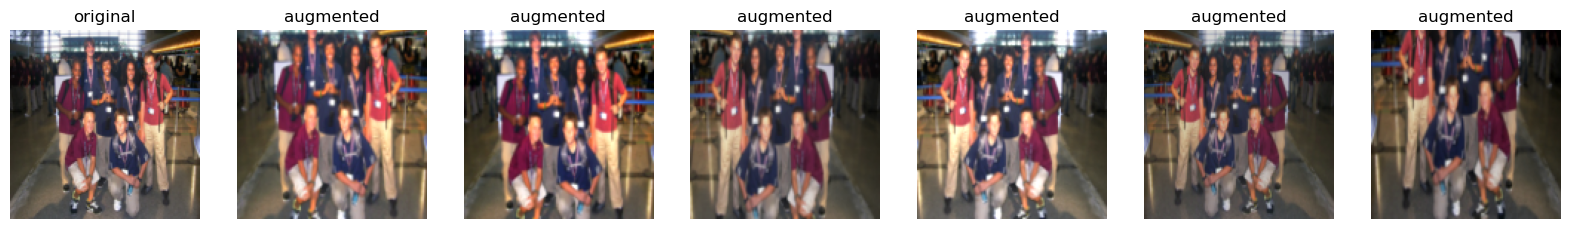

In [6]:
# Looking at augmented versions of one training image
plain_set = Hotdog_NotHotdog(train=True, transform=make_transform(CNN_SIZE, augment=False))
aug_set = Hotdog_NotHotdog(train=True, transform=make_transform(CNN_SIZE, augment=True))
plt.figure(figsize=(20, 4))
plt.subplot(1, 7, 1)
plt.imshow(plain_set[0][0].permute(1, 2, 0))
plt.title('original')
plt.axis('off')
for k in range(2, 8):
    plt.subplot(1, 7, k)
    plt.imshow(aug_set[0][0].permute(1, 2, 0))
    plt.title('augmented')
    plt.axis('off')
plt.show()

Now create a model and train it!


In [7]:
# Models: normalization layer and own CNN
class Normalize(nn.Module):
    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


def conv_block(c_in, c_out, use_bn):
    layers = [nn.Conv2d(c_in, c_out, 3, padding=1, bias=not use_bn)]
    if use_bn:
        layers.append(nn.BatchNorm2d(c_out))
    return nn.Sequential(*layers, nn.ReLU(), nn.MaxPool2d(2))


class HotdogCNN(nn.Module):
    def __init__(self, size=128, use_bn=True, dropout=0.0, num_classes=2):
        super().__init__()
        self.normalize = Normalize()
        self.convolutional = nn.Sequential(
            conv_block(3, 16, use_bn),
            conv_block(16, 32, use_bn),
            conv_block(32, 64, use_bn),
        )
        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64 * (size // 8) ** 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.fully_connected(self.convolutional(self.normalize(x)))

In [8]:
# Lecture slide network: FC version (fully_conv=False) and convolutional version (fully_conv=True)
class SlideNet(nn.Module):
    def __init__(self, num_classes=2, fully_conv=False):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        if fully_conv:
            self.head = nn.Sequential(
                nn.Conv2d(16, 400, kernel_size=5), nn.ReLU(),
                nn.Conv2d(400, 400, kernel_size=1), nn.ReLU(),
                nn.Conv2d(400, num_classes, kernel_size=1),
            )
        else:
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(5 * 5 * 16, 400), nn.ReLU(),
                nn.Linear(400, 400), nn.ReLU(),
                nn.Linear(400, num_classes),
            )

    def forward(self, x):
        return self.head(self.features(x))

In [9]:
# Lecture slide: the FC and convolutional versions compute the same function
fc_net, conv_net = SlideNet(4), SlideNet(4, fully_conv=True)
conv_net.features.load_state_dict(fc_net.features.state_dict())
linears = [m for m in fc_net.head if isinstance(m, nn.Linear)]
convs = [m for m in conv_net.head if isinstance(m, nn.Conv2d)]
with torch.no_grad():
    for lin, conv in zip(linears, convs):
        conv.weight.copy_(lin.weight.view_as(conv.weight))
        conv.bias.copy_(lin.bias)
        print(f"{tuple(lin.weight.shape)} -> {tuple(conv.weight.shape)}: "
              f"{sum(p.numel() for p in lin.parameters())} vs {sum(p.numel() for p in conv.parameters())} parameters")
    x = torch.randn(8, 3, 14, 14)
    print('Same output on 14x14 input:', torch.allclose(fc_net(x), conv_net(x).flatten(1), atol=1e-5))
    big = torch.randn(1, 3, 16, 16)
    grid = conv_net(big)
    same = all(torch.allclose(grid[0, :, i, j], fc_net(big[:, :, 2*i:2*i + 14, 2*j:2*j + 14])[0], atol=1e-5)
               for i in range(2) for j in range(2))
    print('16x16 input gives output', tuple(grid.shape), '- each cell equals the FC net on a 14x14 window:', same)

(400, 400) -> (400, 16, 5, 5): 160400 vs 160400 parameters
(400, 400) -> (400, 400, 1, 1): 160400 vs 160400 parameters
(4, 400) -> (4, 400, 1, 1): 1604 vs 1604 parameters
Same output on 14x14 input: True
16x16 input gives output (1, 4, 2, 2) - each cell equals the FC net on a 14x14 window: True


In [ ]:
# Models: ResNet-34 for transfer learning
def make_resnet(pretrained, num_classes=2):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return nn.Sequential(Normalize(), model)

In [ ]:
# Training and evaluation
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        total_loss += criterion(out, y).item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def train_model(model, optimizer, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        val_loss, val_acc = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(correct / total)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch + 1}/{epochs}: train loss {total_loss / total:.4f}, train acc {correct / total:.4f}, "
              f"val loss {val_loss:.4f}, val acc {val_acc:.4f}")
    model.load_state_dict(best_state)
    history['best_val_acc'] = best_val_acc
    return history

In [ ]:
# Experiment runner
CNN_EPOCHS = 15
RESNET_EPOCHS = 10
runs = {}


def run_experiment(name, make_model, opt_name, lr, size, augment, epochs, batch_size=64):
    print(f"\n=== {name} ===")
    torch.manual_seed(0)
    model = make_model().to(device)
    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    train_loader, val_loader, _ = make_loaders(size, augment, batch_size)
    history = train_model(model, optimizer, train_loader, val_loader, epochs)
    runs[name] = {'model': model, 'history': history, 'size': size}

In [ ]:
# Experiments: own CNN, optimizer x augmentation x batch norm
for opt_name, lr in [('adam', 1e-3), ('sgd', 1e-2)]:
    for augment in [False, True]:
        for use_bn in [False, True]:
            name = f"cnn_{opt_name}_lr={lr}_aug={augment}_bn={use_bn}_drop=0.0"
            run_experiment(name, lambda: HotdogCNN(CNN_SIZE, use_bn), opt_name, lr, CNN_SIZE, augment, CNN_EPOCHS)

In [ ]:
# Experiments: ResNet-34 from scratch vs pretrained
for pretrained in [False, True]:
    run_experiment(f"resnet34_pretrained={pretrained}", lambda: make_resnet(pretrained),
                   'adam', 1e-4, RESNET_SIZE, True, RESNET_EPOCHS, batch_size=32)

In [ ]:
# Learning curves (dashed = train, solid = validation)
def names_with(*parts):
    return [name for name in runs if all(p in name for p in parts)]


def plot_curves(names, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for name in names:
        h = runs[name]['history']
        line, = axes[0].plot(h['val_loss'], label=name)
        axes[0].plot(h['train_loss'], '--', color=line.get_color())
        axes[1].plot(h['val_acc'], color=line.get_color(), label=name)
        axes[1].plot(h['train_acc'], '--', color=line.get_color())
    axes[0].set_ylabel('loss')
    axes[1].set_ylabel('accuracy')
    for ax in axes:
        ax.set_xlabel('epoch')
        ax.legend(fontsize=8)
    fig.suptitle(title)
    plt.show()


plot_curves(names_with('cnn_adam_lr=0.001_', 'drop=0.0'), 'Own CNN with Adam: augmentation and batch norm')
plot_curves(names_with('cnn_sgd'), 'Own CNN with SGD: augmentation and batch norm')
plot_curves(names_with('cnn_adam', 'aug=True_bn=True'), 'Own CNN: learning rate and dropout')
plot_curves(names_with('resnet34'), 'ResNet-34: from scratch vs pretrained')

In [ ]:
# Results: validation and test accuracy of every run, model selection on validation
test_loaders = {size: make_loaders(size, augment=False)[2] for size in {run['size'] for run in runs.values()}}
for name, run in runs.items():
    run['test_acc'] = evaluate(run['model'], test_loaders[run['size']])[1]
    print(f"{name:45s} val acc {run['history']['best_val_acc']:.4f}   test acc {run['test_acc']:.4f}")

best_name = max(runs, key=lambda name: runs[name]['history']['best_val_acc'])
best_model = runs[best_name]['model']
test_loader = test_loaders[runs[best_name]['size']]
test_set = test_loader.dataset
print(f"\nSelected on validation: {best_name} (test acc {runs[best_name]['test_acc']:.4f})")

In [ ]:
# Test-set predictions and confusion matrix of the selected model
@torch.no_grad()
def predict(model, loader):
    model.eval()
    probs, ys = [], []
    for X, y in loader:
        probs.append(model(X.to(device)).softmax(1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)


probs, ys = predict(best_model, test_loader)
preds = probs.argmax(1)
confusion = torch.bincount(ys * 2 + preds, minlength=4).view(2, 2)
print(f"Test accuracy: {(preds == ys).float().mean().item():.4f}")
print(f"Confusion matrix (rows = true, columns = predicted, order {class_names}):")
print(confusion.numpy())

In [ ]:
# Most confident mistakes on the test set
wrong = (preds != ys).nonzero().flatten()
worst = wrong[probs[wrong, preds[wrong]].argsort(descending=True)][:12].tolist()
plt.figure(figsize=(20, 8))
for k, i in enumerate(worst):
    image, label = test_set[i]
    plt.subplot(2, 6, k + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"true: {class_names[label]}\npred: {class_names[preds[i]]} ({probs[i, preds[i]]:.2f})")
    plt.axis('off')
plt.show()

In [ ]:
# Saliency maps: vanilla gradient and SmoothGrad
def compute_saliency(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)
    image.requires_grad_()
    out = model(image)
    score = out[0, target_class]
    model.zero_grad()
    score.backward()
    saliency = image.grad.abs().squeeze().max(dim=0)[0]
    return saliency.cpu().numpy()


def smoothgrad_saliency(model, image, target_class, n_samples=50, sigma=0.15):
    model.eval()
    image = image.to(device)
    total_grad = torch.zeros_like(image)
    for _ in range(n_samples):
        noise = torch.randn_like(image) * sigma
        noisy_image = (image + noise).unsqueeze(0)
        noisy_image.requires_grad_()
        out = model(noisy_image)
        score = out[0, target_class]
        model.zero_grad()
        score.backward()
        total_grad += noisy_image.grad.squeeze()
    avg_grad = total_grad / n_samples
    saliency = avg_grad.abs().max(dim=0)[0]
    return saliency.cpu().numpy()


def show_saliency(model, dataset, idxs, sigma=0.15, n_samples=50):
    fig, axes = plt.subplots(3, len(idxs), figsize=(4 * len(idxs), 12), squeeze=False)
    for col, i in enumerate(idxs):
        image, label = dataset[i]
        model.eval()
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device)).argmax(1).item()
        axes[0, col].imshow(image.permute(1, 2, 0))
        axes[0, col].set_title(f"true: {class_names[label]}, pred: {class_names[pred]}")
        axes[1, col].imshow(compute_saliency(model, image.clone(), pred), cmap='hot')
        axes[1, col].set_title('Vanilla saliency (predicted class)')
        axes[2, col].imshow(smoothgrad_saliency(model, image.clone(), pred, n_samples, sigma), cmap='hot')
        axes[2, col].set_title(f'SmoothGrad (sigma = {sigma})')
    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Saliency for hotdog test images and for the most confident mistakes
hotdog_idxs = (ys == 0).nonzero().flatten()[:4].tolist()
show_saliency(best_model, test_set, hotdog_idxs)
if worst:
    show_saliency(best_model, test_set, worst[:4])

In [ ]:
# SmoothGrad for different noise levels sigma
sigmas = [0.05, 0.15, 0.3, 0.5]
image, label = test_set[hotdog_idxs[0]]
fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(4 * (len(sigmas) + 1), 4))
axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title('Image')
for ax, sigma in zip(axes[1:], sigmas):
    ax.imshow(smoothgrad_saliency(best_model, image.clone(), label, n_samples=50, sigma=sigma), cmap='hot')
    ax.set_title(f'sigma = {sigma}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# First-layer filters: ResNet-34 from scratch vs pretrained
def show_filters(conv, title):
    w = conv.weight.detach().cpu()
    w = (w - w.min()) / (w.max() - w.min())
    fig, axes = plt.subplots(4, 16, figsize=(16, 4.5))
    for ax, f in zip(axes.flat, w):
        ax.imshow(f.permute(1, 2, 0))
        ax.axis('off')
    fig.suptitle(title)
    plt.show()


show_filters(runs['resnet34_pretrained=False']['model'][1].conv1, 'ResNet-34 trained from scratch')
show_filters(runs['resnet34_pretrained=True']['model'][1].conv1, 'ResNet-34 pretrained on ImageNet')